<a href="https://colab.research.google.com/github/karagoz-matias/Data-Science-WPO/blob/main/Exercise_session_8_2025_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WPO 8: CRISP-DM

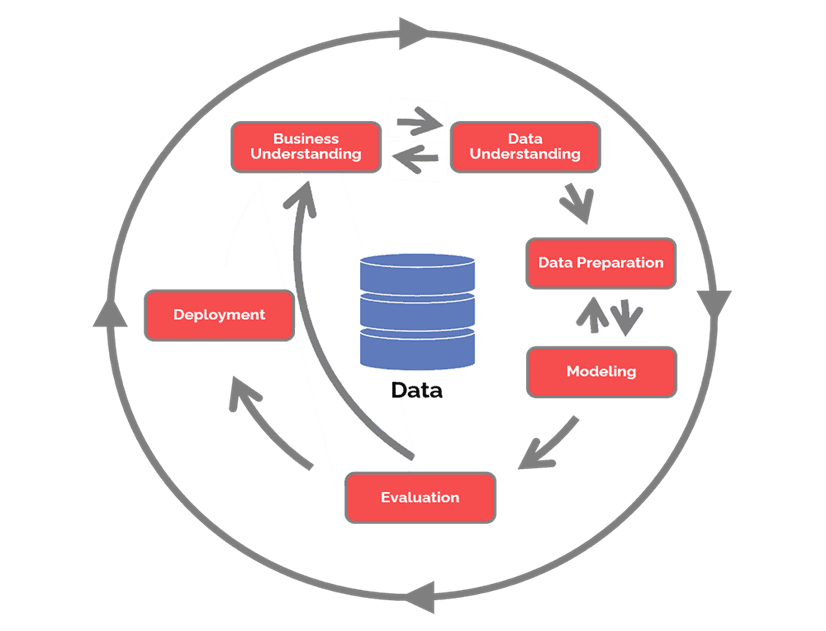

# Exercise 36: On-time delivery prediction

**META DATA**



1.  ID: ID Number of Customers.
2.  Warehouse block: The Company have big Warehouse which is divided in to block such as A,B,C,D,E.
3. Mode of shipment:The Company Ships the products in multiple way such as Ship, Flight and Road.
4. Customer care calls: The number of calls made from enquiry for enquiry of the shipment.
5. Customer rating: The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best).
6. Cost of the product: Cost of the Product in US Dollars.
7. Prior purchases: The Number of Prior Purchase.
8. Product importance: The company has categorized the product in the various parameter such as low, medium, high.
9. Gender: Male and Female.
10. Discount offered: Discount offered on that specific product.
11. Weight in gms: It is the weight in grams.
12. Reached on time: It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time.



## **Step 1:** Business Understanding

What do you know about this (business) data problem? Do you understand what the data is about? What is the meaning of each column? What is the target column? Which questions do you want to answer and why?

**Write answer here:**

1. Which products are the most likely to not be delivered on time?
2. What are the most important drivers of late delivery?
3. How accurate and trustworthy is the model in a real-life context?



## **Step 2:** Data Understanding

What kind of data do we have? Which features does the data contain? What is the target column? Explore the data with “dataframe” methods and matplotlib-visualization techniques.

**Pandas DataFrame methods**

In [3]:
import pandas as pd
otd_data = pd.read_csv("On_Time_Delivery.csv")
otd_data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
otd_data.nunique()

,0
ID,10999
Warehouse_block,5
Mode_of_Shipment,3
Customer_care_calls,6
Customer_rating,5
Cost_of_the_Product,215
Prior_purchases,8
Product_importance,3
Gender,2
Discount_offered,65


In [5]:
otd_data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [6]:
otd_data.drop(["ID"], axis = 1)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,C,Ship,5,4,242,5,low,F,4,1155,0
10997,F,Ship,5,2,223,6,medium,M,2,1210,0


**Matplotlib visualization methods**

In [ ]:
# Pie charts & scatter plots

/tmp/ipython-input-2533558986.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  On_time = otd_data[otd_data['Reached.on.Time_Y.N']==1].count()[0]
/tmp/ipython-input-2533558986.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Too_late = otd_data[otd_data['Reached.on.Time_Y.N']==0].count()[0]


([<matplotlib.patches.Wedge at 0x78f4aaed2d80>,
 [Text(-0.32902379458151726, 1.0496396251091036, 'On time'),
  Text(0.3290242617242808, -1.0496394786767467, 'Too late')])

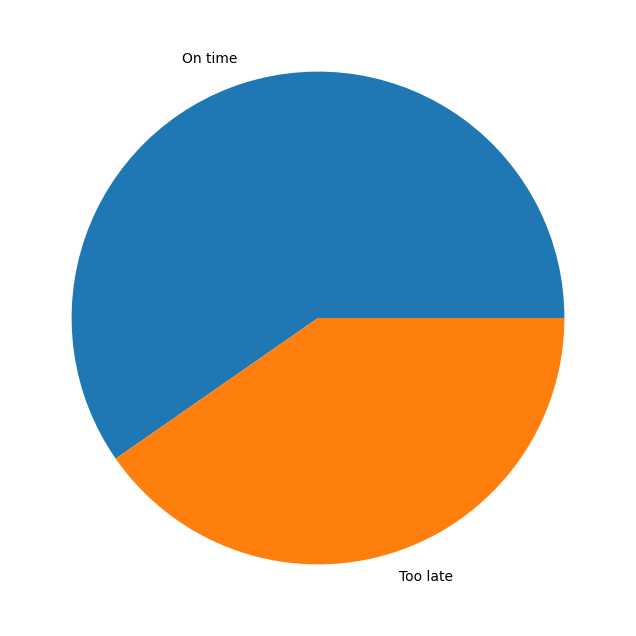

In [7]:
import matplotlib.pyplot as plt
fig, ax= plt.subplots(figsize = (10,8))
On_time = otd_data[otd_data['Reached.on.Time_Y.N']==1].count()[0]
Too_late = otd_data[otd_data['Reached.on.Time_Y.N']==0].count()[0]
ax.pie([On_time, Too_late],labels =["On time", "Too late"] )

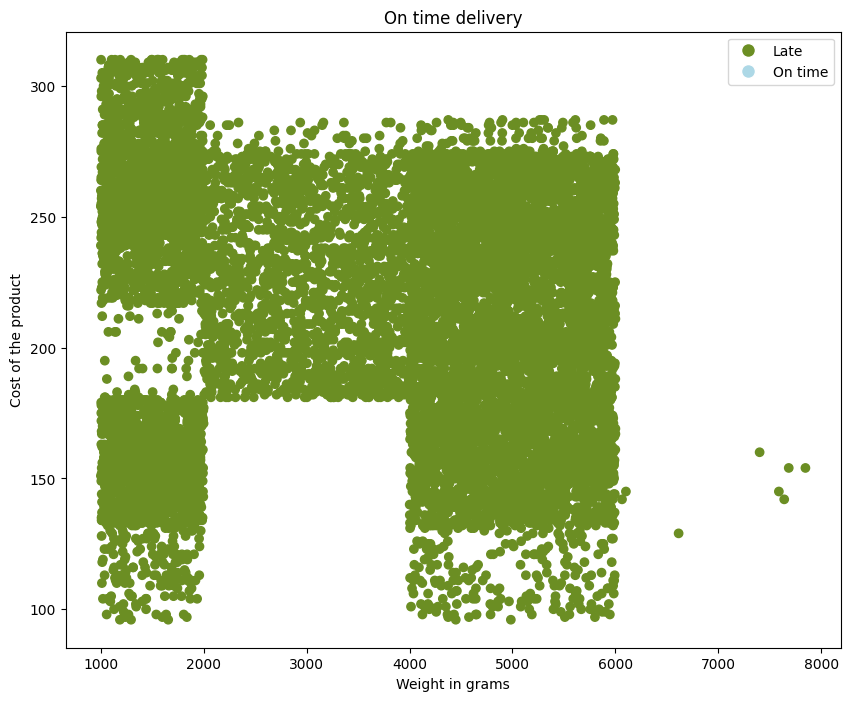

In [26]:
import matplotlib.pyplot as plt
import numpy as np

col = 'Reached.on.Time_Y.N'

colors = ["olivedrab", "lightblue"]  # 0 → greenish, 1 → blue
color_map = [colors[c] for c in otd_data[col]]

fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(
    otd_data['Weight_in_gms'],
    otd_data['Cost_of_the_Product'],
    c=color_map
)

labels = ["Late", "On time"]   # 0 → Late, 1 → On time

ax.legend(
    handles=[
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=color,
            markersize=10,
            label=label
        )
        for color, label in zip(colors, labels)
    ]
)


ax.set_title("On time delivery")
ax.set_xlabel("Weight in grams")
ax.set_ylabel("Cost of the product")

plt.show()


## **Step 3:** Data Preparation

Data is not always “clean” enough to be used by a machine learning algorithm:
  

1.   Missing values (A)
2.   Categories might be encoded as words instead of numbers (B)
3.   Features might be at different scales (C)

Remember that not all these steps are necessary for all models.

**A) Missing Values**

In [28]:
otd_data.isna().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


**B) Encode Categorical Features**

In [38]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Correctly instantiate OrdinalEncoder
OE = OrdinalEncoder()
Ordinal_cols = ['Gender', 'Product_importance']
otd_data[Ordinal_cols] = OE.fit_transform(otd_data[Ordinal_cols])

# Correctly instantiate OneHotEncoder and use correct column names
OHE = OneHotEncoder(drop = "first", sparse_output= False, feature_name_combiner = 'concat')
OHE_cols = ["Warehouse_block", "Mode_of_Shipment"]

# Fit and transform the data, then create a DataFrame with correct capitalization and dynamic column names
OHE_transformed_data = OHE.fit_transform(otd_data[OHE_cols])
OHE_coded = pd.DataFrame(OHE_transformed_data, columns=OHE.get_feature_names_out(OHE_cols))

**C) Scale Features**

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split

X = otd_data.drop(["Reached.on.Time_Y.N"], axis =1)
y = otd_data["Reached.on.Time_Y.N"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 2, test_size= 0.2, shuffle = False)

## **Step 4:** Modeling

We saw many types of models during the previous exercise sessions. Which models are convenient for this data problem and why?

Interpretable? Very complex? Data Imbalance?     DT, Bagging, Stacking?

**Write answer here:**

**Optimize the different Models through cross-validation Grid Search**

Model A= Logistic Regression

In [ ]:
C=[0.1, 0.2, 0.4, 0.6, 0.8, 0.9,1]
paramlr=dict( C=C)


Model B= Decision Tree

In [ ]:
max_depth=[5, 10, 15, 20, 25, 30, 40, 50,  None]
max_leaf_nodes=[100, 200, 300,  400, 450,500, 1000, None]
parameters=dict(max_depth=max_depth, max_leaf_nodes=max_leaf_nodes)



Model C= Random Forests

In [ ]:
n_estimators=[10,100, 500, 1000, 700]
parameters=dict(max_depth=max_depth, n_estimators=n_estimators)

Model D=

In [ ]:
from sklearn.ensemble import AdaBoostClassifier


## **Step 5:** Evaluation

Which evaluation metric(s) do you want to use to compare the generalization perofrmance and why?

**Write answer here:**

Model A

Model B

Model C

Model D

## **Step 6:** Deployment

What is the final output of the process? What are the results and conclusions?

**Write answer here:**

# Exercise 37: House Price Prediction

Apply every step of the Cross Industry Standard Process for Data Mining to the house pricing dataset.

## **Step 1:** Business Understanding

## **Step 2:** Data Understanding

## **Step 3:** Data Preparation

## **Step 4:** Modeling

## **Step 5:** Evaluation

## **Step 6:** Deployment